# EDA 진행 순서

1. 데이터 기본 정보 확인  
2. 수치형 지표 기초 통계 확인  
3. 원본 / 로그 변환 분포 비교  
4. 0값 비율 및 외부 팬덤 지표 확인  
5. 플랫폼별 주요 지표 비교  
6. 지표 간 상관관계 확인  
7. 파생지표 생성  
8. 세그먼트별 후보군 탐색  
9. EDA 결과 요약 및 모델링 방향 정리

---
### 라이브러리

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import math
from sklearn.preprocessing import MinMaxScaler

### 파일불러오기

In [97]:
df = pd.read_csv("./data/final_softcone.csv", encoding="utf-8-sig")

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

---
# 1. 데이터 기본 정보 확인

In [98]:
df.shape

(11157, 18)

In [99]:
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,False
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,True
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,True
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,True
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,True


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11157 entries, 0 to 11156
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   스트리머명          11157 non-null  str    
 1   플랫폼            11157 non-null  str    
 2   채널ID           11157 non-null  str    
 3   집계기간_내_최초_방송일  11157 non-null  str    
 4   최고_팔로워         11157 non-null  int64  
 5   총_방송시간         11157 non-null  int64  
 6   6분_최고채팅        11157 non-null  int64  
 7   6분_평균채팅_최댓값    11157 non-null  int64  
 8   최고_시청자         11157 non-null  int64  
 9   평균_시청자_최댓값     11157 non-null  int64  
 10  뷰어십            11157 non-null  int64  
 11  도네이션           11157 non-null  int64  
 12  유튜브_유입지수       11157 non-null  float64
 13  팬덤지수           11157 non-null  float64
 14  X_팔로워          11157 non-null  int64  
 15  유튜브_구독자        11157 non-null  int64  
 16  팬카페_가입자        11157 non-null  int64  
 17  팬카페_그룹여부       3953 non-null   object 
dtypes: float64(2), in

In [101]:
df["팬카페_그룹여부"].value_counts(dropna=False)

팬카페_그룹여부
NaN      7204
False    3475
True      478
Name: count, dtype: int64

In [102]:
df["팬카페_그룹여부"].value_counts(dropna=False, normalize=True) * 100

팬카페_그룹여부
NaN      64.569329
False    31.146366
True      4.284306
Name: proportion, dtype: float64

---
# 2. 수치형 지표 기초 통계 확인

In [103]:
df.describe()

,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자
count,11157.000000,11157.000000,11157.000000,11157.000000,11157.000000,11157.000000,1.115700e+04,1.115700e+04,11157.000000,11157.000000,11157.000000,1.115700e+04,11157.00000
mean,2309.257775,1018.317558,374.524245,108.220310,361.722775,181.134714,5.387762e+04,2.378627e+05,-46.016510,-55.965206,488.257238,4.630698e+03,2023.39464
std,12291.828812,1066.586502,1875.241146,401.151273,1846.180432,1106.966436,4.269471e+05,5.815986e+05,51.761132,45.156887,6185.575552,3.984107e+04,29192.00507
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-100.000000,-100.000000,0.000000,0.000000e+00,0.00000
25%,139.000000,228.000000,68.000000,22.000000,14.000000,8.000000,8.590000e+02,2.976000e+03,-100.000000,-100.000000,0.000000,0.000000e+00,0.00000
50%,369.000000,677.000000,110.000000,41.000000,29.000000,16.000000,3.880000e+03,2.696500e+04,-40.200000,-55.800000,0.000000,3.000000e+01,0.00000
75%,954.000000,1484.000000,217.000000,74.000000,88.000000,44.000000,1.597900e+04,1.919710e+05,-8.600000,-20.000000,6.000000,3.380000e+02,41.00000
max,413862.000000,18654.000000,108416.000000,17283.000000,47218.000000,30958.000000,1.707500e+07,7.043167e+06,816.000000,437.300000,351000.000000,2.210000e+06,573411.00000


In [104]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
최고_팔로워,11157.0,2309.257775,12291.828812,0.0,139.0,369.0,954.0,413862.0
총_방송시간,11157.0,1018.317558,1066.586502,0.0,228.0,677.0,1484.0,18654.0
6분_최고채팅,11157.0,374.524245,1875.241146,0.0,68.0,110.0,217.0,108416.0
6분_평균채팅_최댓값,11157.0,108.220310,401.151273,0.0,22.0,41.0,74.0,17283.0
최고_시청자,11157.0,361.722775,1846.180432,0.0,14.0,29.0,88.0,47218.0
평균_시청자_최댓값,11157.0,181.134714,1106.966436,0.0,8.0,16.0,44.0,30958.0
뷰어십,11157.0,53877.616205,426947.139323,0.0,859.0,3880.0,15979.0,17075004.0
도네이션,11157.0,237862.724926,581598.602288,0.0,2976.0,26965.0,191971.0,7043167.0
유튜브_유입지수,11157.0,-46.016510,51.761132,-100.0,-100.0,-40.2,-8.6,816.0
팬덤지수,11157.0,-55.965206,45.156887,-100.0,-100.0,-55.8,-20.0,437.3


In [105]:
for col in num_cols:
    print(f"\n[{col}]")
    print(df[col].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]))


[최고_팔로워]
0.00         0.00
0.25       139.00
0.50       369.00
0.75       954.00
0.90      2919.00
0.95      7366.80
0.99     39390.96
1.00    413862.00
Name: 최고_팔로워, dtype: float64

[총_방송시간]
0.00        0.00
0.25      228.00
0.50      677.00
0.75     1484.00
0.90     2443.40
0.95     3124.20
0.99     4523.88
1.00    18654.00
Name: 총_방송시간, dtype: float64

[6분_최고채팅]
0.00         0.0
0.25        68.0
0.50       110.0
0.75       217.0
0.90       642.4
0.95      1335.4
0.99      4433.0
1.00    108416.0
Name: 6분_최고채팅, dtype: float64

[6분_평균채팅_최댓값]
0.00        0.00
0.25       22.00
0.50       41.00
0.75       74.00
0.90      162.00
0.95      327.20
0.99     1559.52
1.00    17283.00
Name: 6분_평균채팅_최댓값, dtype: float64

[최고_시청자]
0.00        0.0
0.25       14.0
0.50       29.0
0.75       88.0
0.90      398.0
0.95     1232.4
0.99     7645.4
1.00    47218.0
Name: 최고_시청자, dtype: float64

[평균_시청자_최댓값]
0.00        0.00
0.25        8.00
0.50       16.00
0.75       44.00
0.90      169.00
0.95      453.

---
## 3. 원본 / 로그 변환 분포 비교

본 단계에서는 주요 수치형 지표의 원본 분포와 로그 변환 분포를 비교하여 데이터의 치우침 정도를 확인하였다.

스트리머 데이터는 일부 대형 스트리머에게 팔로워, 시청자, 후원, 외부 팬덤 지표가 크게 집중될 가능성이 높다. 따라서 원본 분포만 확인하면 대부분의 일반 후보군이 낮은 구간에 몰려 보이고, 극단값의 영향으로 전체 구조를 해석하기 어렵다.

이에 따라 다음 세 가지 방식으로 분포를 확인하였다.

1. 원본 전체 분포  
2. 상위 1% 극단값을 제외한 원본 분포  
3. `log1p()` 변환 후 분포

이를 통해 각 지표의 롱테일 여부, 0값 집중 여부, 로그 변환 필요성을 함께 판단하였다.

---
### 3-1. 원본 전체 분포

In [106]:
check_cols = [
    "최고_팔로워",
    "총_방송시간",
    "6분_최고채팅",
    "6분_평균채팅_최댓값",
    "최고_시청자",
    "평균_시청자_최댓값",
    "뷰어십",
    "도네이션",
    "유튜브_구독자",
    "X_팔로워",
    "팬카페_가입자"
]

# df에 실제로 존재하는 컬럼만 남기기
check_cols = [col for col in check_cols if col in df.columns]

print("분석에 사용할 컬럼:")
print(check_cols)

분석에 사용할 컬럼:
['최고_팔로워', '총_방송시간', '6분_최고채팅', '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_구독자', 'X_팔로워', '팬카페_가입자']


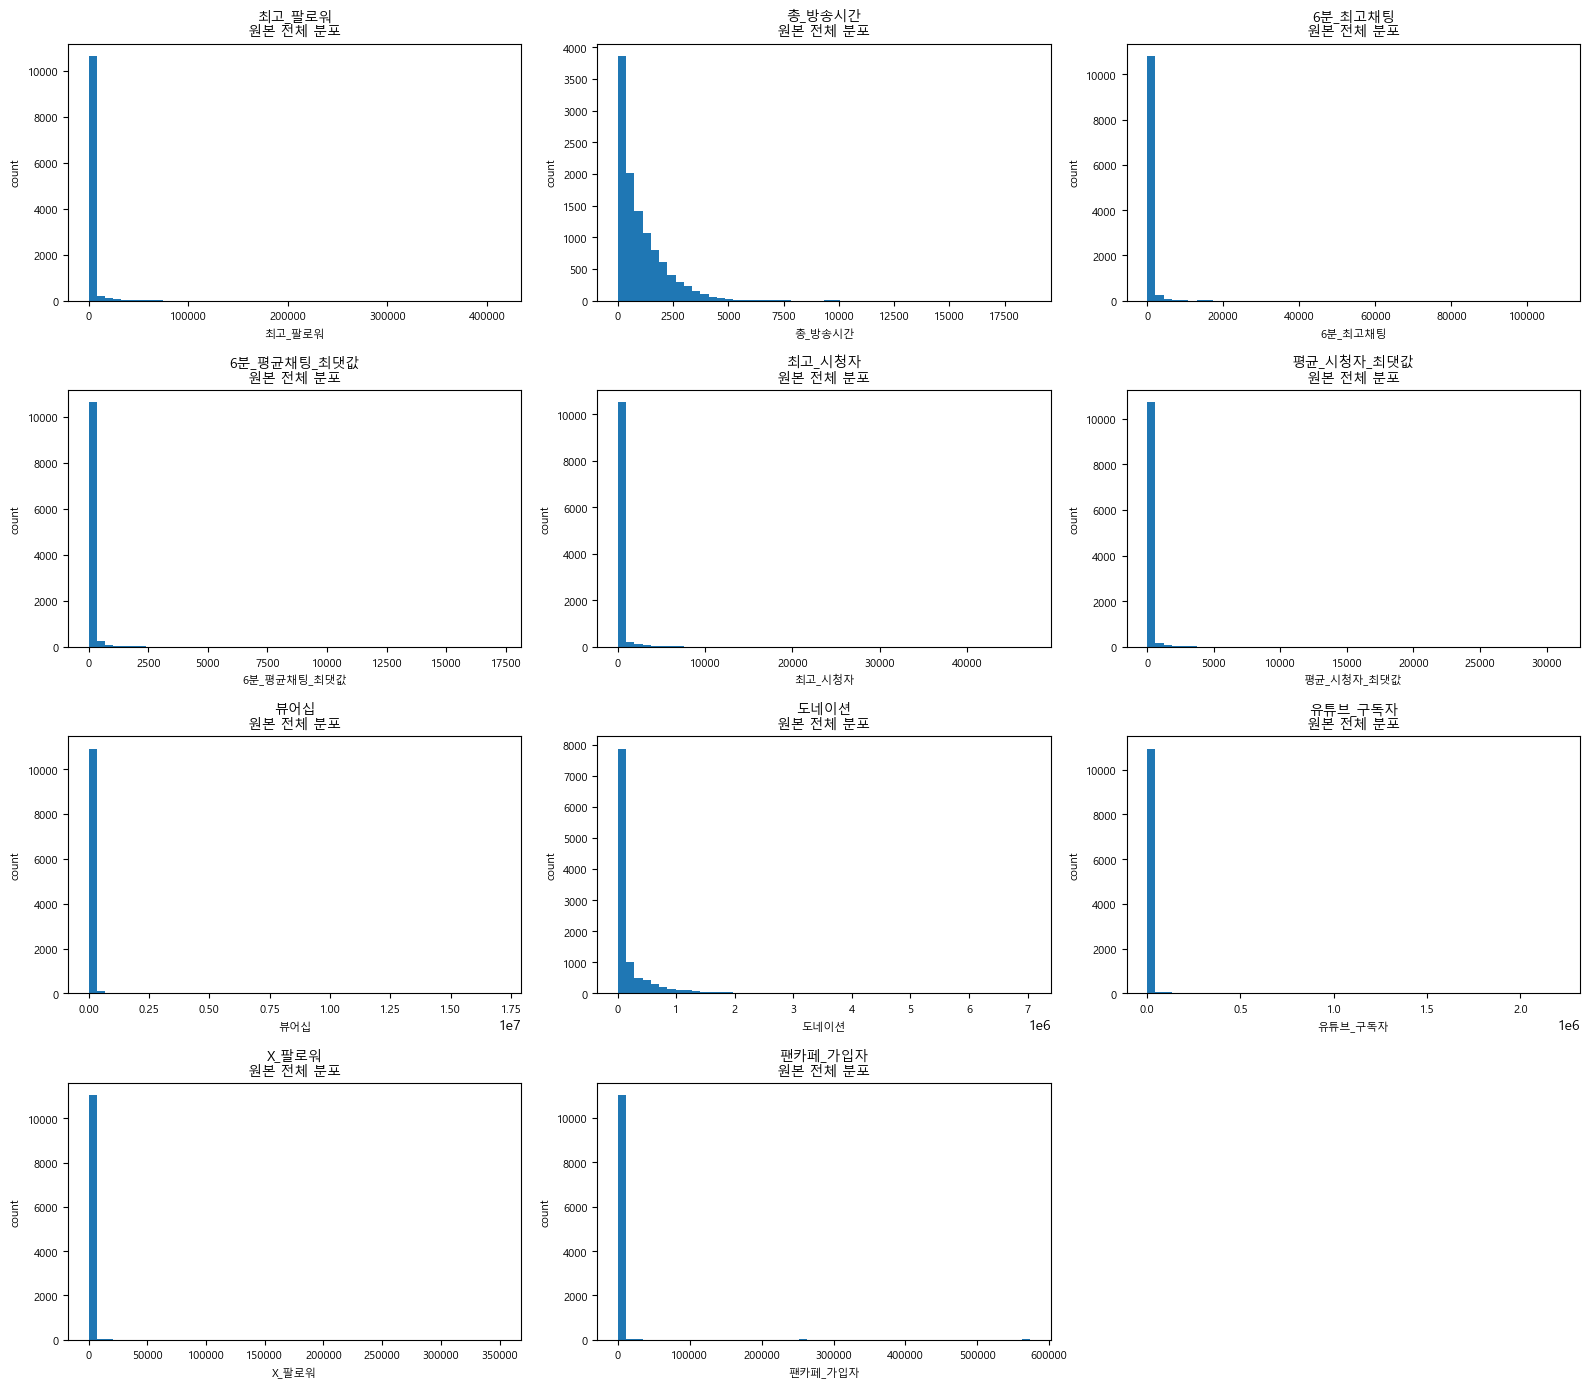

In [107]:
n_cols = 3
n_rows = math.ceil(len(check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    
    # 음수만 제거, 0은 포함
    s = s[s >= 0]

    if s.empty:
        axes[i].set_visible(False)
        continue

    axes[i].hist(s, bins=50)
    axes[i].set_title(f"{col}\n원본 전체 분포", fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("count", fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

# 남는 빈 그래프 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
### 3-2.상위 1% 극단값을 제외한 원본 분포  

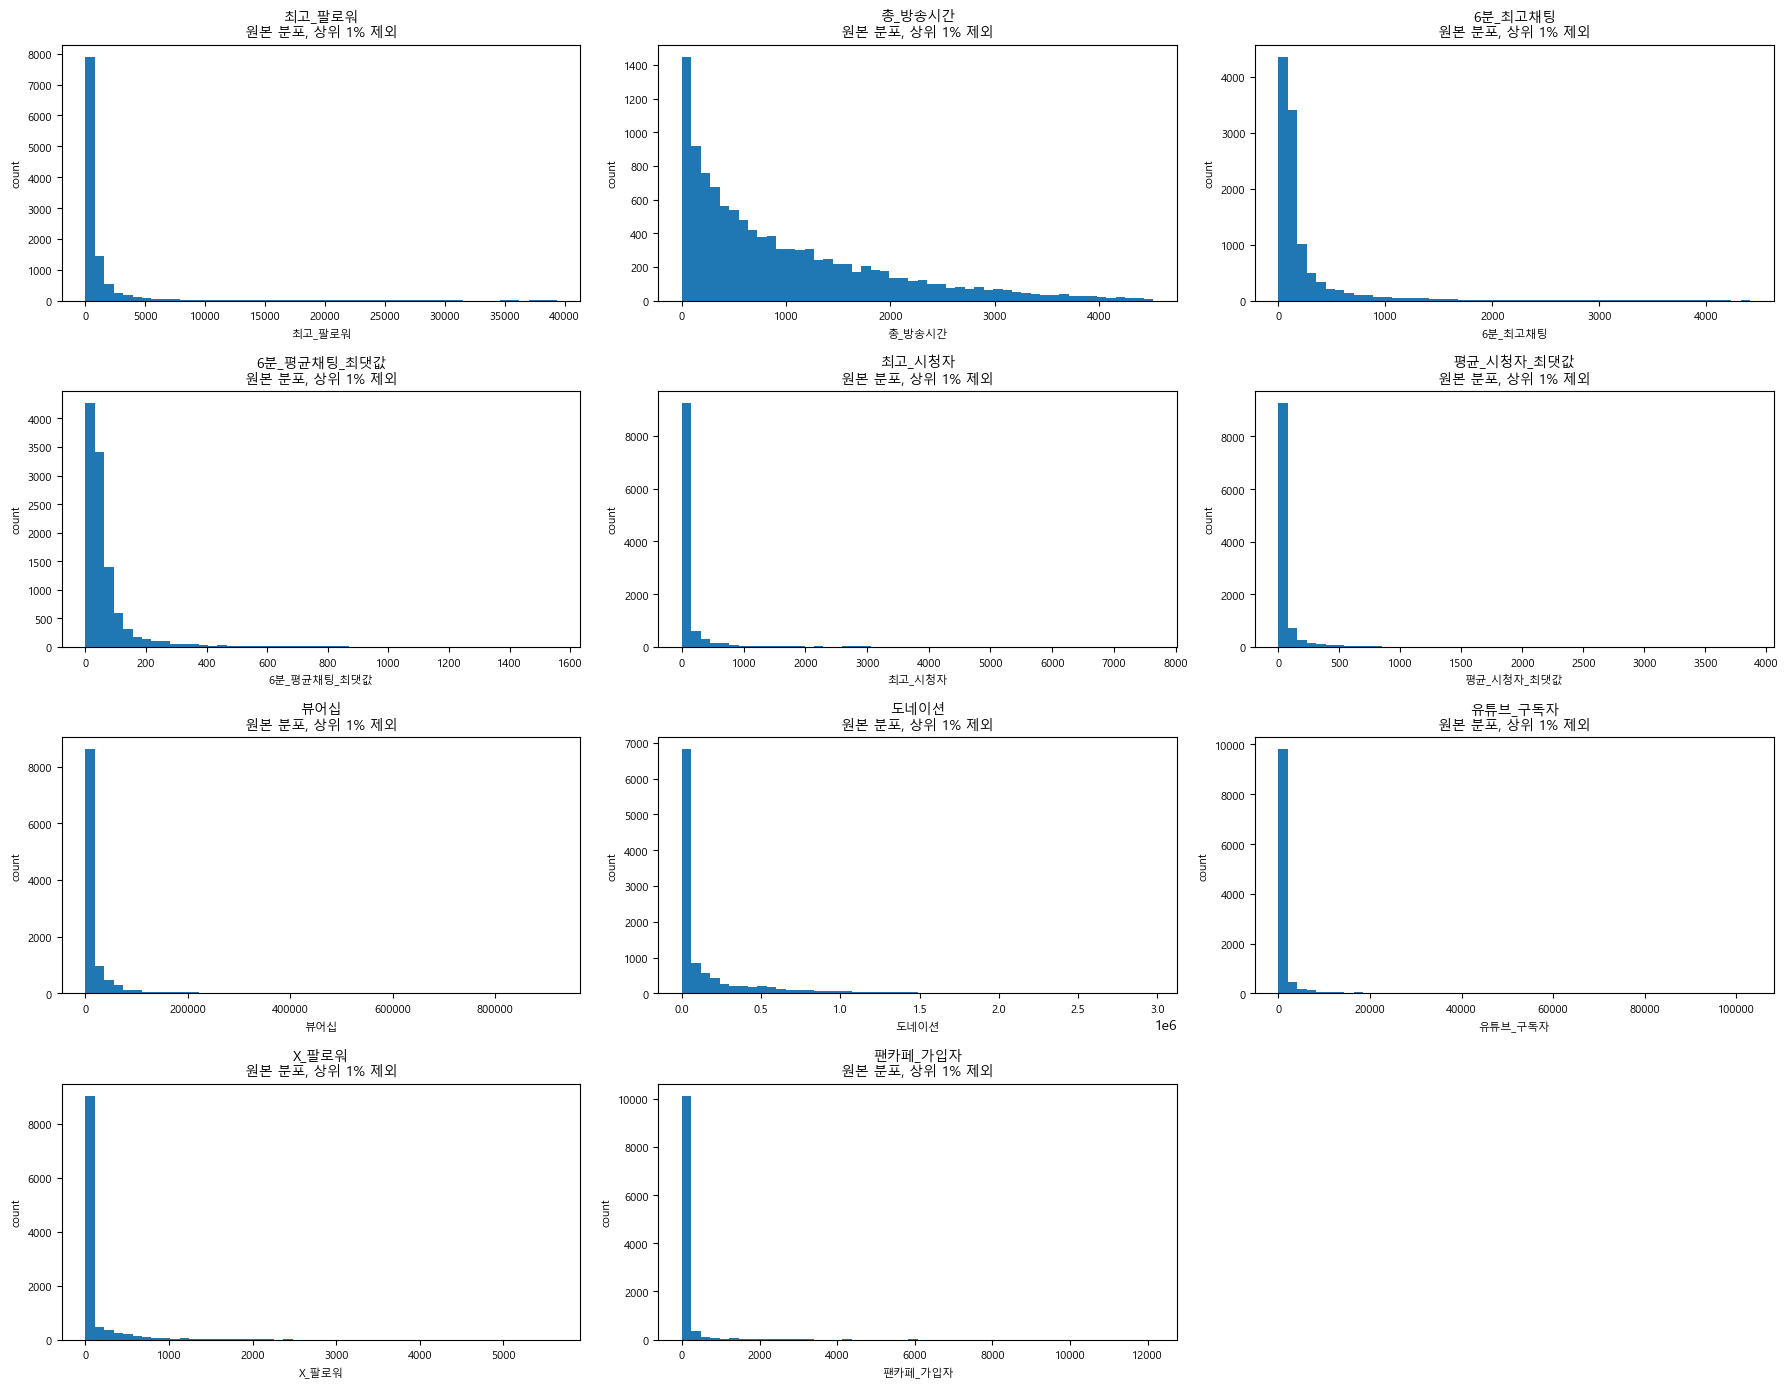

In [108]:
n_cols = 3
n_rows = math.ceil(len(check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s >= 0]

    if s.empty:
        axes[i].set_visible(False)
        continue

    upper = s.quantile(0.99)
    s_cut = s[s <= upper]

    axes[i].hist(s_cut, bins=50)
    axes[i].set_title(f"{col}\n원본 분포, 상위 1% 제외", fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("count", fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

# 남는 빈 그래프 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
### 3-3. `log1p()` 변환 후 분포

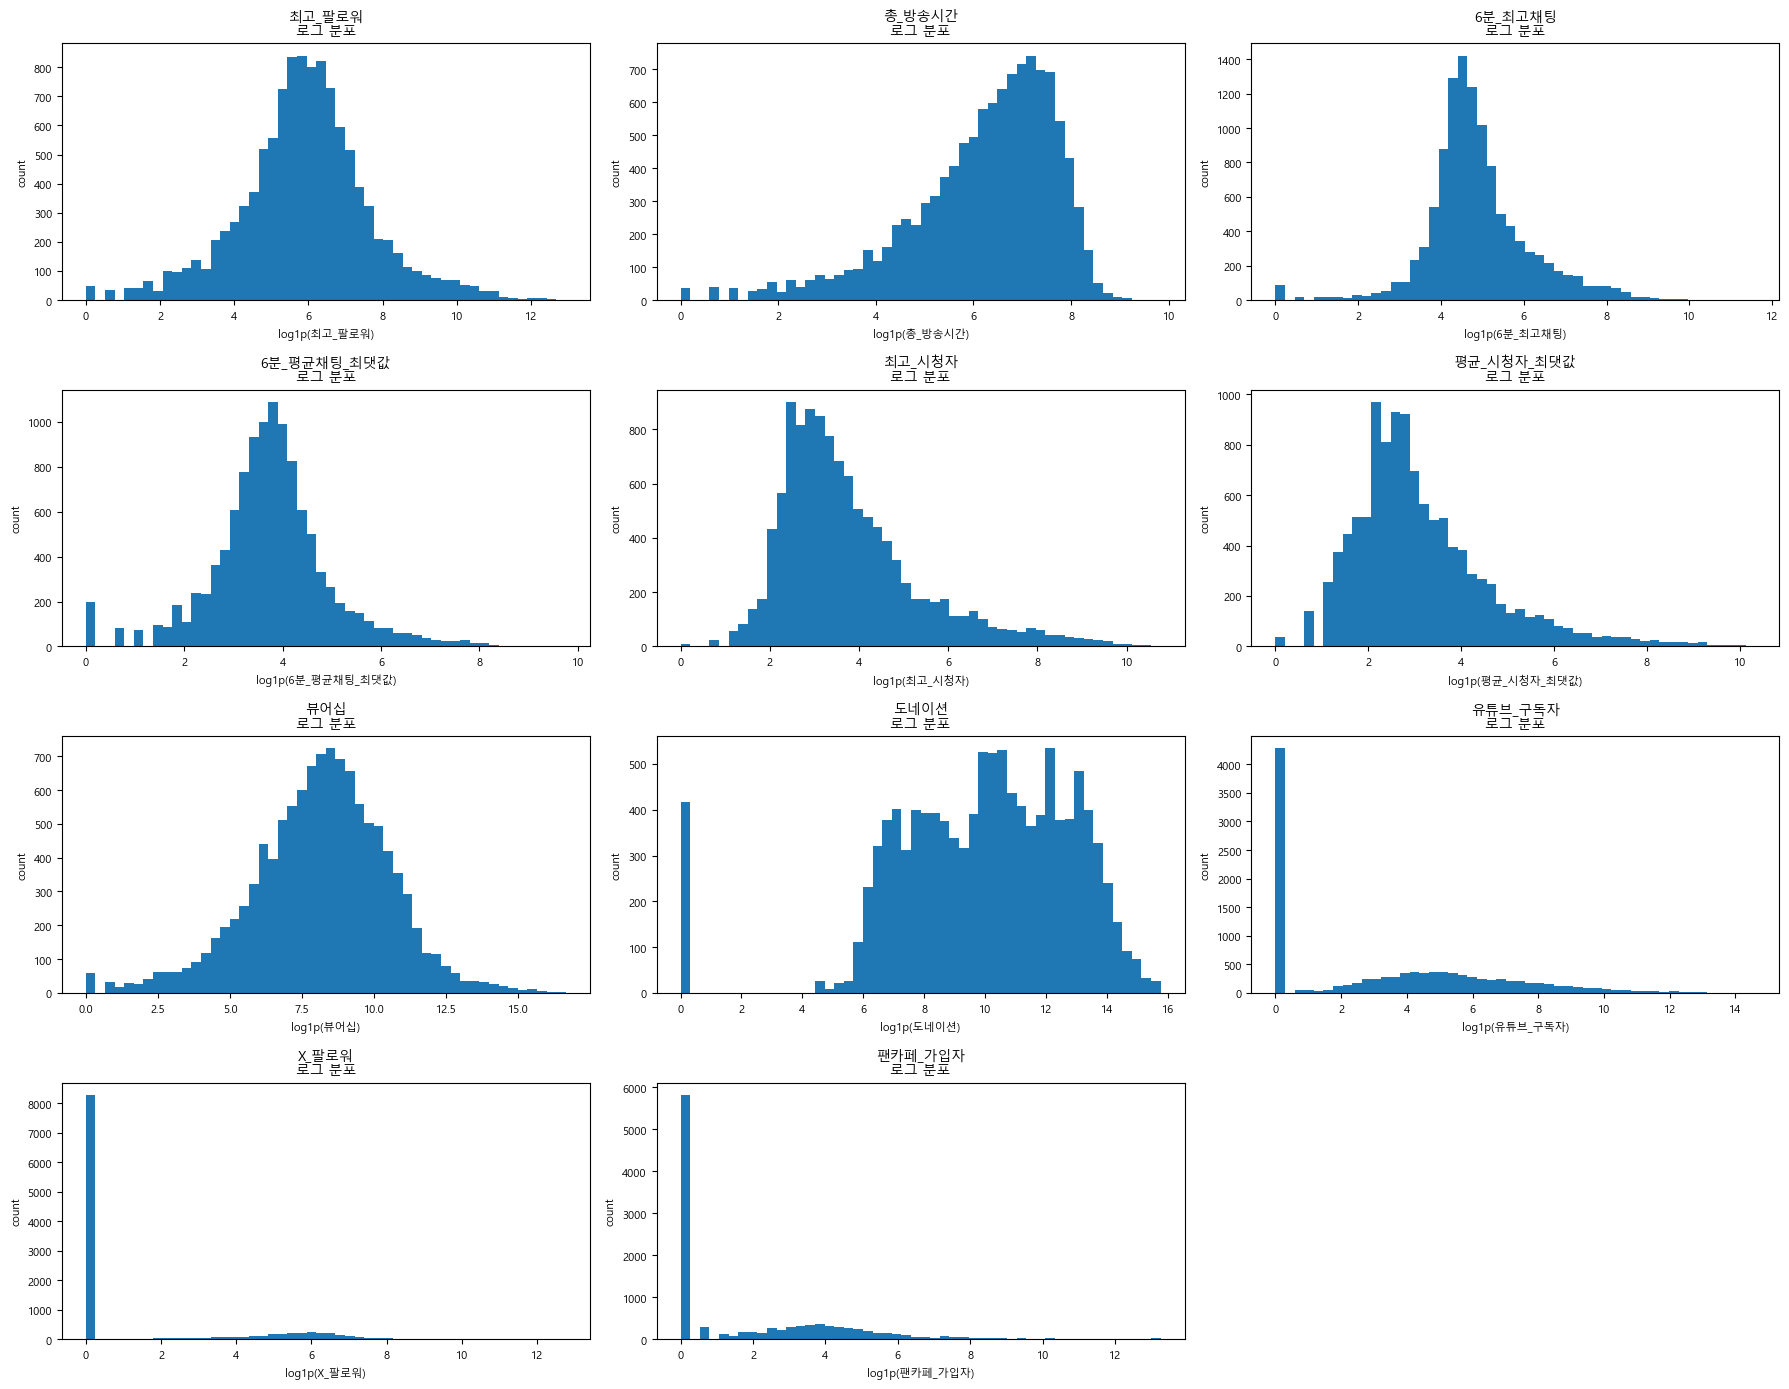

In [109]:
n_cols = 3
n_rows = math.ceil(len(check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s >= 0]

    if s.empty:
        axes[i].set_visible(False)
        continue

    axes[i].hist(np.log1p(s), bins=50)
    axes[i].set_title(f"{col}\n로그 분포", fontsize=10)
    axes[i].set_xlabel(f"log1p({col})", fontsize=8)
    axes[i].set_ylabel("count", fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

# 남는 빈 그래프 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

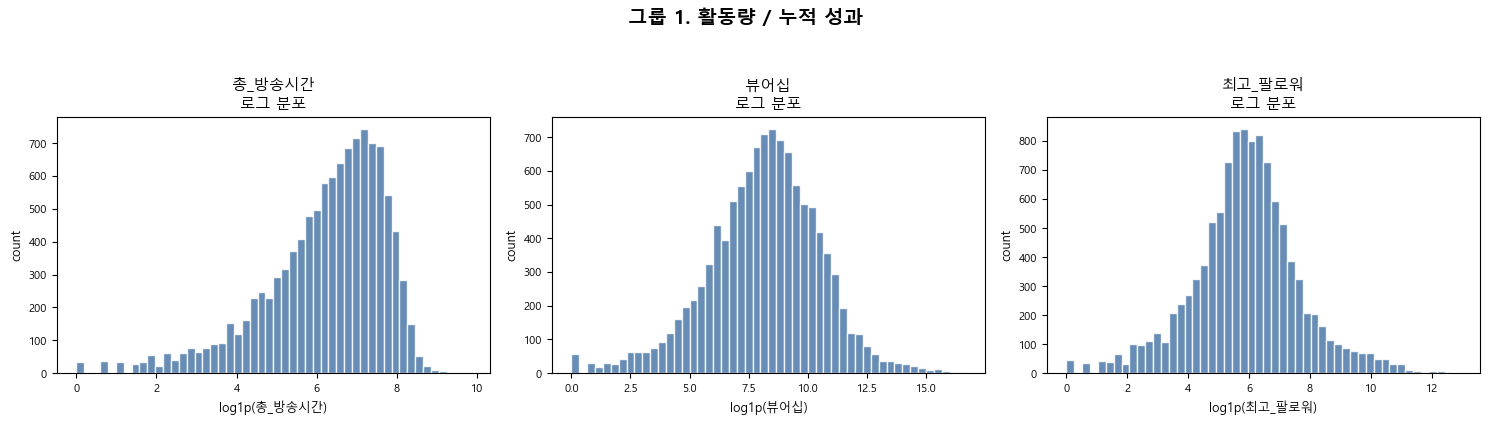

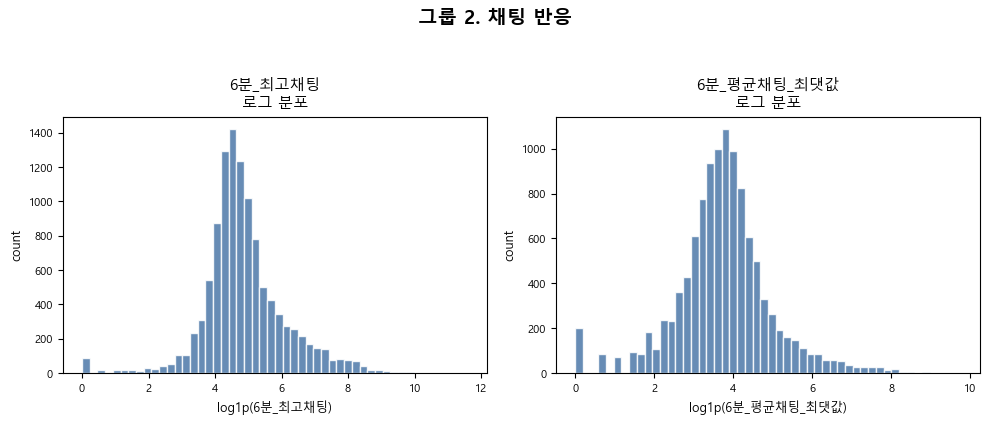

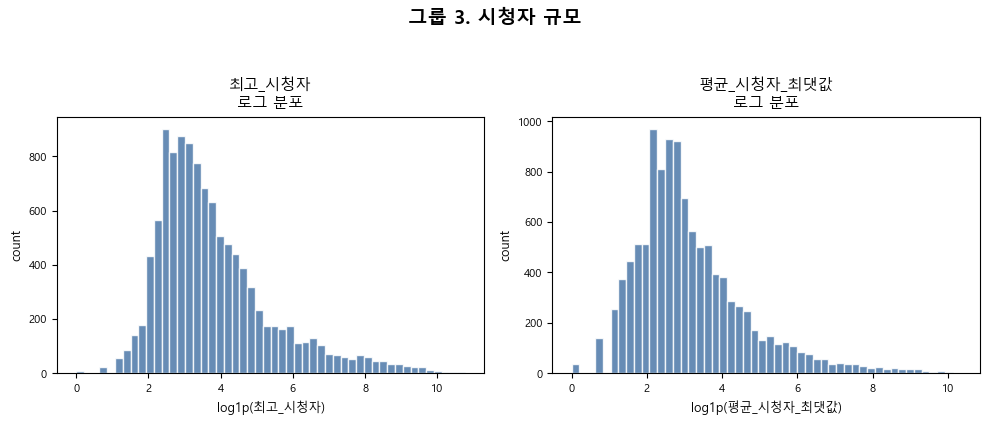

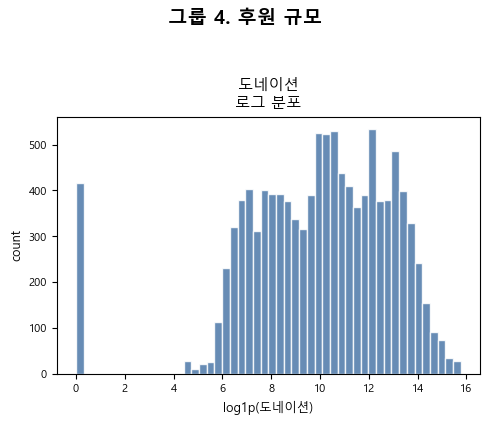

In [110]:
hist_groups = {
    "그룹 1. 활동량 / 누적 성과": ["총_방송시간", "뷰어십", "최고_팔로워"],
    "그룹 2. 채팅 반응": ["6분_최고채팅", "6분_평균채팅_최댓값"],
    "그룹 3. 시청자 규모": ["최고_시청자", "평균_시청자_최댓값"],
    "그룹 4. 후원 규모": ["도네이션"]
}

for group_name, cols in hist_groups.items():
    n_cols = len(cols)
    n_rows = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4))

    # 그래프가 1개일때도 처리되게끔
    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(cols):
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        s = s[s >= 0]

        if s.empty:
            axes[i].set_visible(False)
            continue

        axes[i].hist(
            np.log1p(s),
            bins=50,
            color="#4C78A8",
            edgecolor="white",
            alpha=0.85
        )

        axes[i].set_title(f"{col}\n로그 분포", fontsize=11)
        axes[i].set_xlabel(f"log1p({col})", fontsize=9)
        axes[i].set_ylabel("count", fontsize=9)
        axes[i].tick_params(axis="both", labelsize=8)

    fig.suptitle(group_name, fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

## 로그 변환 히스토그램 해석

주요 수치형 지표의 분포를 확인한 결과, 대부분의 지표에서 일부 상위 스트리머의 값이 매우 크게 나타났다.  
즉, 원본값을 그대로 비교하면 대형 스트리머의 영향이 너무 커서 일반적인 후보군의 차이를 보기 어렵다.

따라서 이후 분석에서는 큰 값의 영향을 줄이기 위해 `log1p()` 변환값을 사용한다.  
또한 외부 팬덤 지표는 0값이 많기 때문에, 단순 수치뿐 아니라 외부 채널 보유 여부도 함께 확인한다.

### 지표별 해석 요약

- **총_방송시간**  
  로그 변환 후 분포가 비교적 안정적으로 나타났다. 스트리머가 얼마나 꾸준히 활동했는지 비교하는 데 활용할 수 있다.

- **뷰어십**  
  로그 변환 후 중심 구간이 뚜렷하게 나타났다. 누적 시청 성과와 플랫폼 유입력을 비교하는 주요 지표로 볼 수 있다.

- **최고_시청자 / 평균_시청자_최댓값**  
  일부 스트리머에게 값이 크게 몰려 있다. 대형 스트리머와 중소형 스트리머의 체급 차이를 확인할 수 있다.

- **6분_최고채팅 / 6분_평균채팅_최댓값**  
  시청자 반응과 팬덤 활동성을 볼 수 있는 지표다. 단순 채팅 수뿐 아니라 시청자 수 대비 채팅 비율도 함께 보는 것이 좋다.

- **도네이션**  
  수익성을 볼 수 있는 핵심 지표지만 편차가 크다. 총 후원금뿐 아니라 시청자 수 대비 후원 효율도 함께 확인할 필요가 있다.


---
# 4. 0값 비율 및 외부 팬덤 지표 확인

목적 : 0값 비율은 각 지표가 분석에 안정적으로 활용 가능한지 확인하기 위해 살펴보았다.  
특히 외부 팬덤 지표의 0값은 실제 팬덤이 없다는 의미뿐 아니라, 외부 채널 미보유나 수집 불가로 인해 발생했을 가능성도 있다.  

따라서 0값 비율이 높은 지표는 단순 수치 비교보다, 해당 채널의 보유 여부와 보유자 내 규모를 분리하여 해석할 필요가 있다.

---
### 4-1. 0값 비율

In [111]:
zero_summary = []

for col in check_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    valid_s = s.dropna()

    zero_count = (valid_s == 0).sum()
    positive_count = (valid_s > 0).sum()
    valid_count = len(valid_s)

    zero_summary.append({
        "컬럼": col,
        "유효 행 수": valid_count,
        "0 개수": zero_count,
        "0 비율(%)": round(zero_count / valid_count * 100, 2),
        "0 초과 개수": positive_count,
        "0 초과 비율(%)": round(positive_count / valid_count * 100, 2),
        "최솟값": valid_s.min(),
        "최댓값": valid_s.max()
    })

zero_summary_df = pd.DataFrame(zero_summary)
zero_summary_df.sort_values("0 비율(%)", ascending=False)

,컬럼,유효 행 수,0 개수,0 비율(%),0 초과 개수,0 초과 비율(%),최솟값,최댓값
9,X_팔로워,11157,8280,74.21,2877,25.79,0,351000
10,팬카페_가입자,11157,5819,52.16,5338,47.84,0,573411
8,유튜브_구독자,11157,4277,38.33,6880,61.67,0,2210000
7,도네이션,11157,416,3.73,10741,96.27,0,7043167
3,6분_평균채팅_최댓값,11157,200,1.79,10957,98.21,0,17283
2,6분_최고채팅,11157,86,0.77,11071,99.23,0,108416
6,뷰어십,11157,58,0.52,11099,99.48,0,17075004
0,최고_팔로워,11157,47,0.42,11110,99.58,0,413862
5,평균_시청자_최댓값,11157,38,0.34,11119,99.66,0,30958
1,총_방송시간,11157,35,0.31,11122,99.69,0,18654


---
### 4-2. 외부 팬덤 지표 확인 

외부 팬덤 지표는 원본 분포에서 낮은 값 구간에 데이터가 과도하게 몰려 있어, 보유자 간 규모 차이를 해석하기 어려웠다.  
따라서 0값을 제외한 보유자만 대상으로 `log1p()` 변환 후 분포를 확인하였다.

해당 그래프는 외부 팬덤 지표의 값이 0인 대상을 제외하고, 실제 수치가 존재하는 스트리머만 대상으로 분포를 확인한 것이다.  
따라서 외부 채널 미보유 또는 수집 불가로 0 처리된 대상은 제외되었으며, 보유자 내 팬덤 규모 차이를 비교하기 위한 그래프로 해석한다.

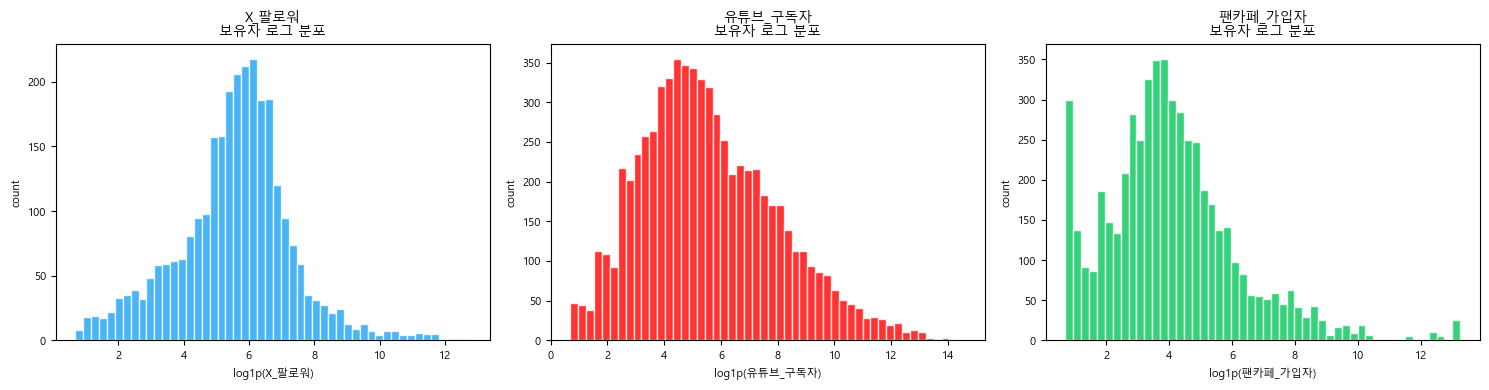

In [112]:
fan_cols = ["X_팔로워", "유튜브_구독자", "팬카페_가입자"]

fan_colors = {
    "X_팔로워": "#1DA1F2",       # 옛날 Twitter 블루
    "유튜브_구독자": "#FF0000",  # YouTube 레드
    "팬카페_가입자": "#03C75A"   # Naver 그린
}

n_cols = 3
n_rows = math.ceil(len(fan_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4))
axes = axes.flatten()

for i, col in enumerate(fan_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s > 0]

    axes[i].hist(
        np.log1p(s),
        bins=50,
        color=fan_colors[col],
        edgecolor="white",
        alpha=0.8
    )

    axes[i].set_title(f"{col}\n보유자 로그 분포", fontsize=10)
    axes[i].set_xlabel(f"log1p({col})", fontsize=8)
    axes[i].set_ylabel("count", fontsize=8)
    axes[i].tick_params(axis="both", labelsize=8)

plt.tight_layout()
plt.show()

### 외부 팬덤 지표 보유자 분포 해석

외부 팬덤 지표는 0값 비중이 높기 때문에, 전체 대상이 아니라 해당 지표를 보유한 스트리머만 따로 분포를 확인하였다.

`X_팔로워`와 `유튜브_구독자`는 로그 변환 후 중심 구간이 비교적 뚜렷하게 나타났다. 이는 외부 채널 보유자 내에서도 일반적인 규모 구간이 존재하며, 일부 상위 스트리머만 매우 큰 외부 팬덤 규모를 가진다는 것을 의미한다.

`팬카페_가입자`는 상대적으로 분포가 불규칙하고 낮은 구간과 중간 구간이 함께 나타났다. 이는 팬카페 가입자 수가 단순 외부 노출 규모뿐 아니라 팬덤 결집도 성격을 함께 가질 수 있음을 의미한다.

따라서 외부 팬덤 지표는 전체 대상 기준으로는 보유 여부를 먼저 확인하고, 보유자 기준으로는 `log1p()` 변환값을 활용해 규모 차이를 비교하는 것이 적절하다.

---
## 5. 플랫폼별 주요 지표 비교

전체 분포를 확인한 뒤, 플랫폼별로 주요 지표의 차이가 있는지 확인하였다.  
플랫폼에 따라 시청자 규모, 방송 활동량, 채팅 반응, 후원 규모가 다를 수 있으므로, 평균보다 극단값의 영향을 덜 받는 중앙값을 중심으로 비교하였다.

In [113]:
platform_plot_cols = [
    "최고_팔로워",
    "총_방송시간",
    "6분_최고채팅",
    "6분_평균채팅_최댓값",
    "최고_시청자",
    "평균_시청자_최댓값",
    "뷰어십",
    "도네이션"
]

In [114]:
platform_median = df.groupby("플랫폼")[platform_plot_cols].median()
platform_median

,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션
플랫폼,,,,,,,,
CHZZK,335.0,608.0,99.0,38.0,26.0,14.0,3130.0,21478.0
SOOP,822.0,1221.5,274.5,61.0,76.0,35.0,14526.0,131666.5


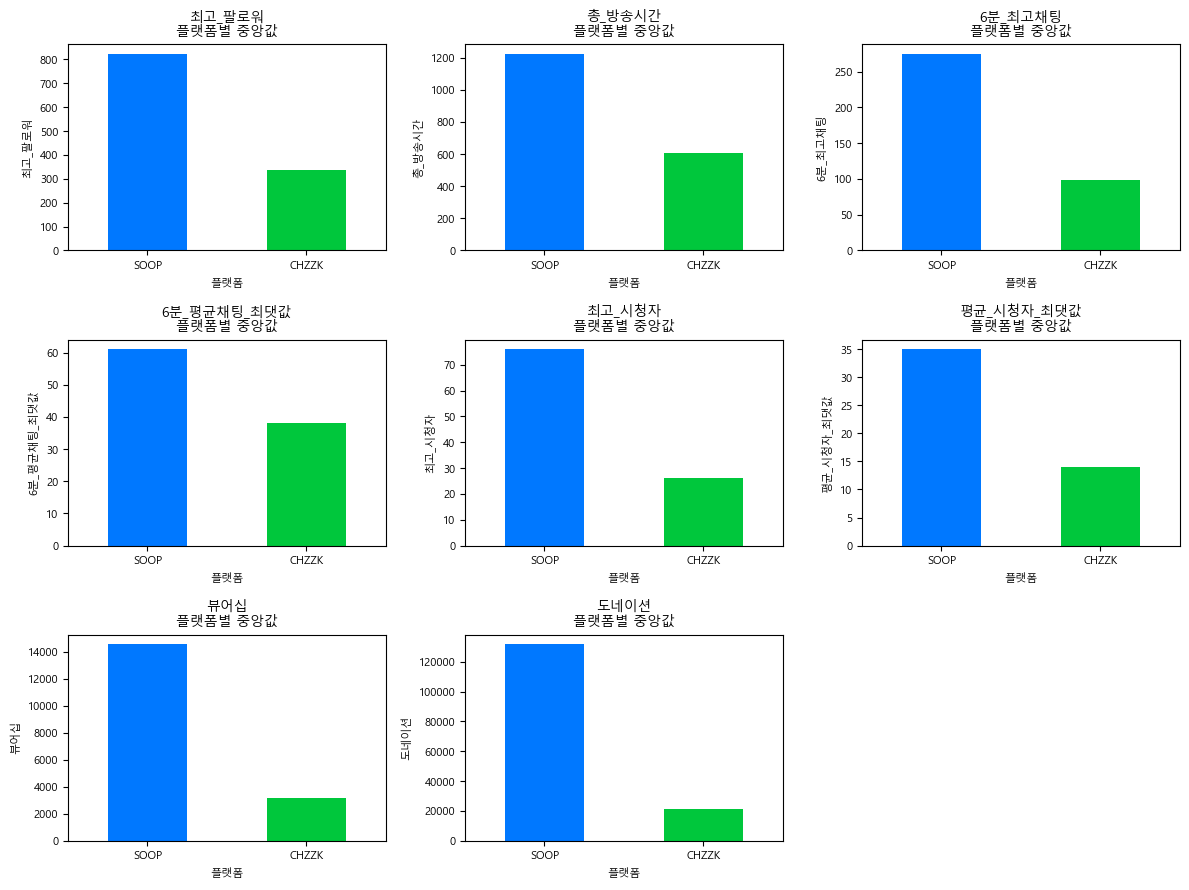

In [115]:
platform_colors = {
    "SOOP": "#0078FF",
    "CHZZK": "#00C73C"
}
n_cols = 3
n_rows = math.ceil(len(platform_plot_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(platform_plot_cols):
    data = platform_median[col].sort_values(ascending=False)
    colors = [platform_colors.get(platform, "gray") for platform in data.index]

    data.plot(
        kind="bar",
        ax=axes[i],
        color=colors
    )

    axes[i].set_title(f"{col}\n플랫폼별 중앙값", fontsize=10)
    axes[i].set_xlabel("플랫폼", fontsize=8)
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].tick_params(axis="x", rotation=0, labelsize=8)
    axes[i].tick_params(axis="y", labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 플랫폼별 비교 요약

중앙값 기준으로 SOOP이 CHZZK보다 방송시간, 시청자 수, 채팅 수, 뷰어십, 도네이션 지표가 전반적으로 높게 나타났다.  
이는 SOOP 스트리머들이 평균적인 활동량과 팬덤 반응, 후원 규모 측면에서 더 큰 체급을 보이는 경향이 있음을 의미한다.

특히 뷰어십과 도네이션 차이가 크게 나타나, SOOP은 누적 시청 성과와 수익성 측면에서 강한 플랫폼으로 해석할 수 있다.  
다만 이는 플랫폼 전체의 중앙값 비교이므로, 이후 분석에서는 개별 스트리머 단위의 성장성·팬덤 밀도·후원 효율을 함께 확인할 필요가 있다.

---
## 6. 지표 간 상관관계 확인

주요 수치형 지표들이 서로 어떤 관계를 가지는지 확인하기 위해 상관관계를 분석하였다.  
상관관계는 두 지표가 함께 증가하거나 감소하는 경향을 보여주며, 이후 파생지표 생성과 영입 점수 산정에 참고할 수 있다.

다만 상관관계가 높다고 해서 반드시 원인과 결과 관계를 의미하는 것은 아니므로, 지표 간 연관성 확인 목적으로 해석한다.


---
### 6-1.원본 상관계수 확인

In [116]:
corr_cols = [
    "최고_팔로워",
    "총_방송시간",
    "6분_최고채팅",
    "6분_평균채팅_최댓값",
    "최고_시청자",
    "평균_시청자_최댓값",
    "뷰어십",
    "도네이션",
    "유튜브_유입지수",
    "팬덤지수",
    "X_팔로워",
    "유튜브_구독자",
    "팬카페_가입자"
]

In [117]:
corr_df = df[corr_cols].corr()
corr_df

,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자
최고_팔로워,1.000000,0.184960,0.481312,0.615691,0.762207,0.732406,0.781668,0.648312,0.128720,0.117503,0.284969,0.545735,0.376965
총_방송시간,0.184960,1.000000,0.155419,0.118252,0.191989,0.126299,0.178404,0.480368,0.110016,0.003120,0.009696,0.075733,0.020120
6분_최고채팅,0.481312,0.155419,1.000000,0.793864,0.567142,0.573474,0.512050,0.462310,0.093004,0.095732,0.062854,0.280858,0.370834
6분_평균채팅_최댓값,0.615691,0.118252,0.793864,1.000000,0.718042,0.768908,0.610306,0.539478,0.131461,0.143862,0.171953,0.347827,0.461703
최고_시청자,0.762207,0.191989,0.567142,0.718042,1.000000,0.936506,0.757517,0.664660,0.117550,0.119160,0.256773,0.376364,0.393812
평균_시청자_최댓값,0.732406,0.126299,0.573474,0.768908,0.936506,1.000000,0.729331,0.597942,0.110417,0.115290,0.250050,0.373757,0.422296
뷰어십,0.781668,0.178404,0.512050,0.610306,0.757517,0.729331,1.000000,0.664935,0.091087,0.100050,0.267027,0.390423,0.356005
도네이션,0.648312,0.480368,0.462310,0.539478,0.664660,0.597942,0.664935,1.000000,0.198205,0.183630,0.190547,0.371761,0.213043
유튜브_유입지수,0.128720,0.110016,0.093004,0.131461,0.117550,0.110417,0.091087,0.198205,1.000000,0.400628,0.053925,0.149847,0.039835
팬덤지수,0.117503,0.003120,0.095732,0.143862,0.119160,0.115290,0.100050,0.183630,0.400628,1.000000,0.141810,0.091193,0.138220


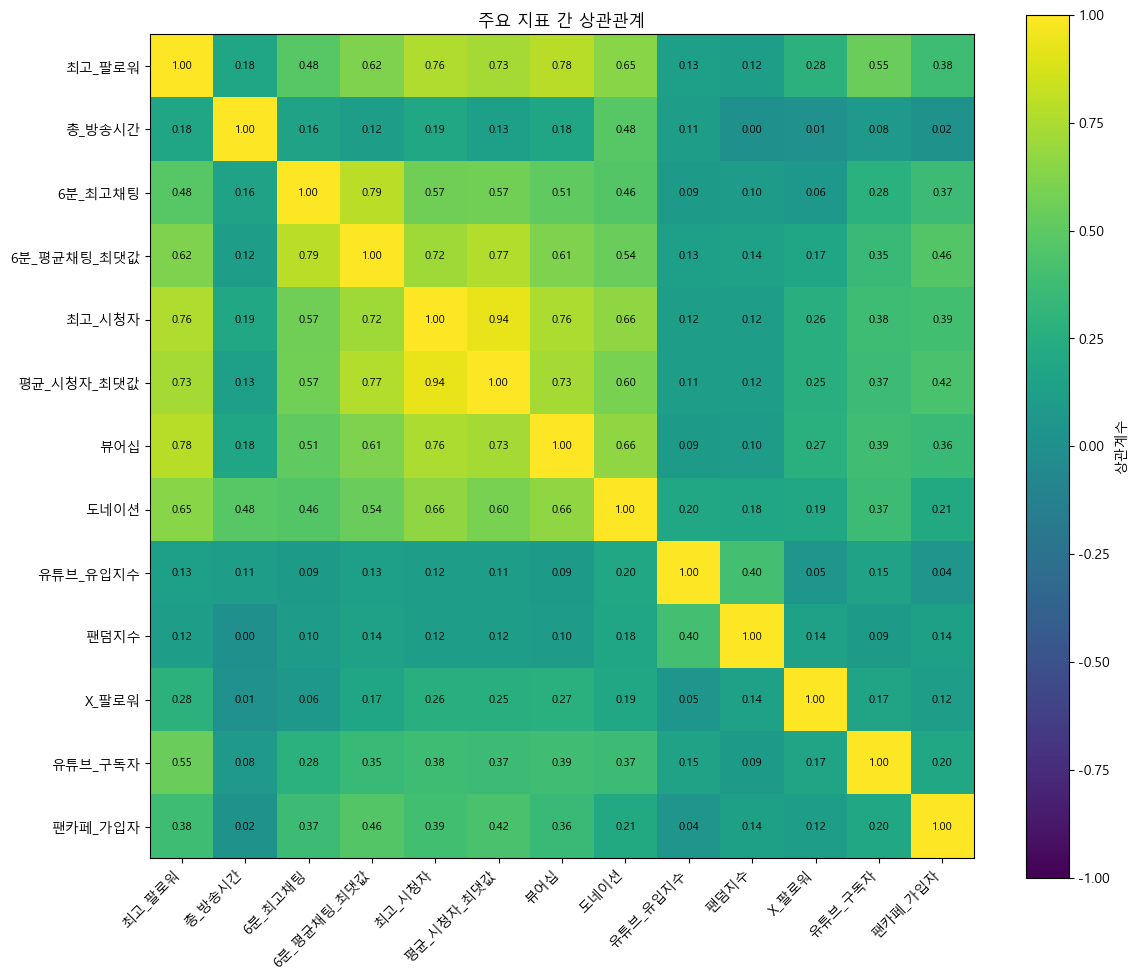

In [118]:
plt.figure(figsize=(12, 10))

im = plt.imshow(corr_df, vmin=-1, vmax=1)

plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.columns)), corr_df.columns)

plt.colorbar(im, label="상관계수")
plt.title("주요 지표 간 상관관계")

for i in range(len(corr_df.columns)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j, i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

---
### 6-2.로그변환 상관계수 확인

In [119]:
log_corr_df = np.log1p(df[corr_cols]).corr()
log_corr_df

c:\python_course\04.최종프로젝트\sparta17_data11_final_project\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
c:\python_course\04.최종프로젝트\sparta17_data11_final_project\.venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자
최고_팔로워,1.000000,0.677493,0.801844,0.769479,0.803615,0.810331,0.878184,0.852605,-0.217703,-0.098511,0.201523,0.599551,0.573958
총_방송시간,0.677493,1.000000,0.559002,0.449173,0.501491,0.456084,0.864372,0.741682,-0.128830,-0.157871,-0.000873,0.331473,0.290689
6분_최고채팅,0.801844,0.559002,1.000000,0.914227,0.815482,0.816311,0.805484,0.805330,-0.195911,-0.050010,0.137914,0.480511,0.561338
6분_평균채팅_최댓값,0.769479,0.449173,0.914227,1.000000,0.754026,0.795109,0.738620,0.803793,-0.235090,-0.094020,0.224140,0.498245,0.575450
최고_시청자,0.803615,0.501491,0.815482,0.754026,1.000000,0.963582,0.799370,0.728390,-0.258313,-0.091110,0.139156,0.523743,0.603438
평균_시청자_최댓값,0.810331,0.456084,0.816311,0.795109,0.963582,1.000000,0.794253,0.733619,-0.262693,-0.104384,0.188132,0.550984,0.626964
뷰어십,0.878184,0.864372,0.805484,0.738620,0.799370,0.794253,1.000000,0.901108,-0.231875,-0.160456,0.103638,0.508830,0.530565
도네이션,0.852605,0.741682,0.805330,0.803793,0.728390,0.733619,0.901108,1.000000,-0.230627,-0.142454,0.147986,0.475721,0.500203
유튜브_유입지수,-0.217703,-0.128830,-0.195911,-0.235090,-0.258313,-0.262693,-0.231875,-0.230627,1.000000,0.464065,-0.100270,0.204761,-0.210294
팬덤지수,-0.098511,-0.157871,-0.050010,-0.094020,-0.091110,-0.104384,-0.160456,-0.142454,0.464065,1.000000,0.003534,-0.116056,0.034338


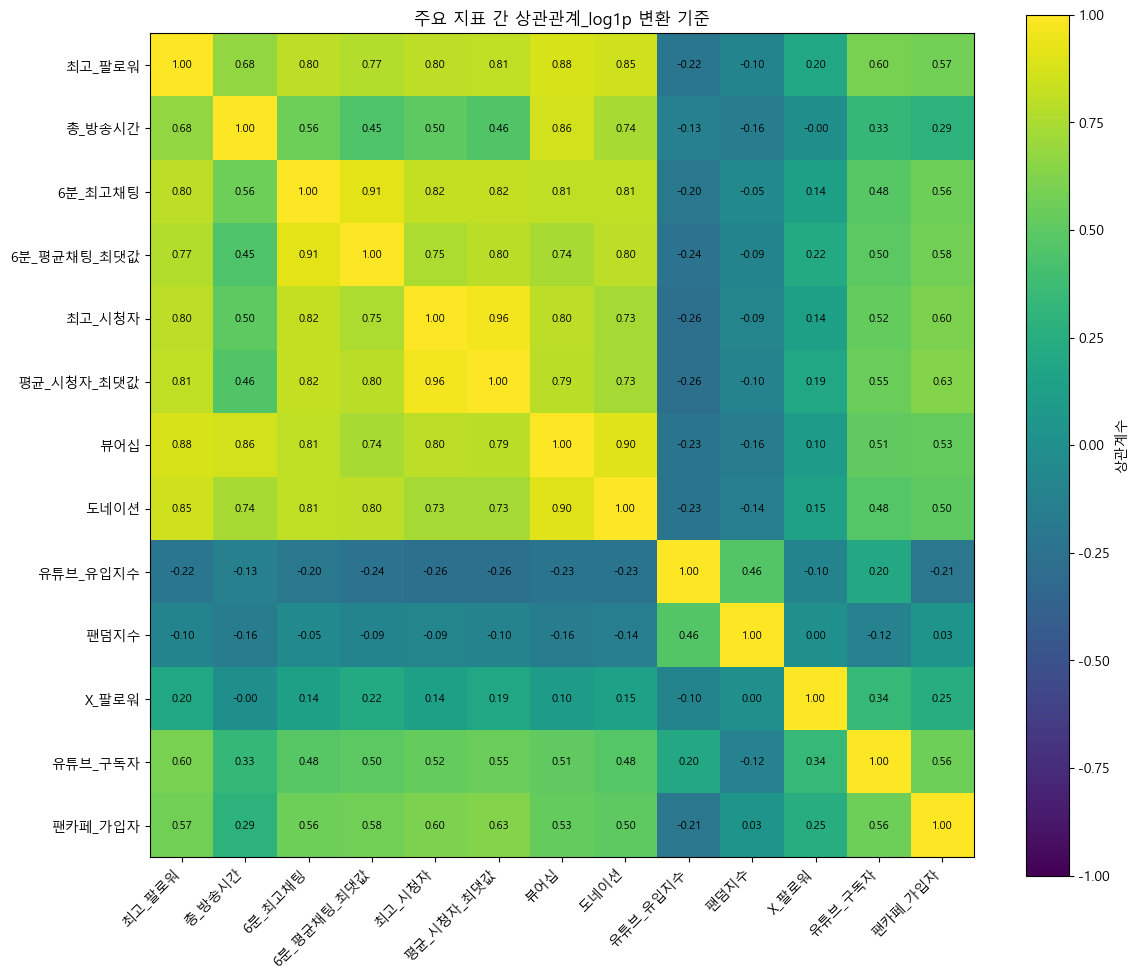

In [120]:
plt.figure(figsize=(12, 10))

im = plt.imshow(log_corr_df, vmin=-1, vmax=1)

plt.xticks(range(len(log_corr_df.columns)), log_corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(log_corr_df.columns)), log_corr_df.columns)

plt.colorbar(im, label="상관계수")
plt.title("주요 지표 간 상관관계_log1p 변환 기준")

for i in range(len(log_corr_df.columns)):
    for j in range(len(log_corr_df.columns)):
        plt.text(
            j, i,
            f"{log_corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

---
### 6-3. 상관계수 TOP10

In [121]:
# 로그 변환 기준 상관관계 사용
corr_matrix = log_corr_df.copy()

# 상관관계 행렬을 긴 형태로 변환
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["지표1", "지표2", "상관계수"]

# 자기 자신과의 상관관계 제거
corr_pairs = corr_pairs[corr_pairs["지표1"] != corr_pairs["지표2"]]

# 중복 제거: A-B, B-A 중 하나만 남기기
corr_pairs["정렬키"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["지표1"], row["지표2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("정렬키").drop(columns="정렬키")

# 상관계수 높은 순 TOP 10
top_corr = corr_pairs.sort_values("상관계수", ascending=False).head(10)

top_corr

,지표1,지표2,상관계수
57,최고_시청자,평균_시청자_최댓값,0.963582
29,6분_최고채팅,6분_평균채팅_최댓값,0.914227
85,뷰어십,도네이션,0.901108
6,최고_팔로워,뷰어십,0.878184
19,총_방송시간,뷰어십,0.864372
7,최고_팔로워,도네이션,0.852605
31,6분_최고채팅,평균_시청자_최댓값,0.816311
30,6분_최고채팅,최고_시청자,0.815482
5,최고_팔로워,평균_시청자_최댓값,0.810331
32,6분_최고채팅,뷰어십,0.805484


### 상관관계 분석 요약

`log1p()` 변환 기준으로 시청자 수, 채팅 수, 뷰어십, 도네이션은 서로 높은 양의 상관관계를 보였다.  
이는 방송 체급이 큰 스트리머일수록 시청자 반응과 후원 규모도 함께 큰 경향이 있음을 의미한다.

특히 `뷰어십`과 `도네이션`의 상관이 높게 나타나, 누적 시청 성과가 수익성과 밀접하게 연결되어 있음을 확인하였다.  
또한 `유튜브_구독자`와 `팬카페_가입자`는 방송 성과 지표와 중간 정도의 양의 상관을 보여 외부 팬덤 규모도 플랫폼 내 성과와 일부 연결되는 것으로 해석할 수 있다.

다만 채팅 수와 도네이션은 시청자 규모의 영향을 크게 받을 수 있으므로, 이후에는 시청자 대비 채팅 밀도와 후원 효율 같은 파생지표를 함께 생성하여 분석이 필요 해 보인다.

---
## 7. 파생지표 생성

상관관계 분석 결과, 시청자 수·채팅 수·뷰어십·도네이션 등 주요 규모 지표들은 서로 높은 양의 상관관계를 보였다.  
이는 규모가 큰 스트리머일수록 대부분의 지표가 함께 크게 나타나는 경향이 있음을 의미한다.

따라서 단순 규모 지표만으로는 스트리머의 세부 특성을 구분하기 어렵다.  
예를 들어 시청자 수가 많은 스트리머는 채팅 수와 후원 규모도 자연스럽게 높게 나타날 수 있으므로, 실제 채팅 반응이 활발한 것인지, 후원 효율이 높은 것인지는 별도로 확인할 필요가 있다.

이에 따라 본 분석에서는 절대 규모의 영향을 줄이고, 스트리머별 상대적 특징을 비교하기 위해 파생지표를 생성했다.

### 생성한 파생지표

| 파생지표 | 계산 기준 | 생성 목적 |
|---|---|---|
| `채팅_밀도` | `6분_평균채팅_최댓값 / 평균_시청자_최댓값` | 시청자 수 대비 채팅 반응 확인 |
| `후원_효율` | `도네이션 / 평균_시청자_최댓값` | 시청자 수 대비 후원 규모 확인 |
| `시간당_뷰어십` | `뷰어십 / 총_방송시간` | 방송시간 대비 시청 성과 확인 |
| `외부채널_보유수` | X, 유튜브, 팬카페 보유 여부 합산 | 외부 팬덤 접점의 다양성 확인 |
| `외부팬덤_합계` | X 팔로워 + 유튜브 구독자 + 팬카페 가입자 | 방송 플랫폼 외부 팬덤 규모 확인 |
| `외부팬덤_비율` | 외부팬덤 합계 / 플랫폼 팔로워 수 | 플랫폼 팔로워 대비 외부 팬덤 규모 확인 |
| `외부팬덤_비율_log` | `log1p(외부팬덤_비율)` | 극단값 완화 후 외부 팬덤 비율 확인 |


---

### 7-1. 파생지표 생성코드

In [122]:
# 원본 보존용 복사
eda_df = df.copy()

# 1) 채팅 밀도: 시청자 수 대비 채팅 반응
eda_df["채팅_밀도"] = (
    eda_df["6분_평균채팅_최댓값"] / (eda_df["평균_시청자_최댓값"] + 1)
)

# 2) 후원 효율: 시청자 수 대비 후원 규모
eda_df["후원_효율"] = (
    eda_df["도네이션"] / (eda_df["평균_시청자_최댓값"] + 1)
)

# 3) 방송시간 대비 뷰어십: 방송시간 대비 누적 시청 성과
eda_df["시간당_뷰어십"] = (
    eda_df["뷰어십"] / (eda_df["총_방송시간"] + 1)
)

# 4) 외부 채널 보유 여부
eda_df["X_보유여부"] = (eda_df["X_팔로워"] > 0).astype(int)
eda_df["유튜브_보유여부"] = (eda_df["유튜브_구독자"] > 0).astype(int)
eda_df["팬카페_보유여부"] = (eda_df["팬카페_가입자"] > 0).astype(int)

# 5) 외부채널 보유 수
eda_df["외부채널_보유수"] = (
    eda_df["X_보유여부"] +
    eda_df["유튜브_보유여부"] +
    eda_df["팬카페_보유여부"]
)

# 6) 외부 팬덤 합계
eda_df["외부팬덤_합계"] = (
    eda_df["X_팔로워"] +
    eda_df["유튜브_구독자"] +
    eda_df["팬카페_가입자"]
)

# 7) 외부 팬덤 비율
eda_df["외부팬덤_비율"] = (
    eda_df["외부팬덤_합계"] / (eda_df["최고_팔로워"] + 1)
)

# 8) 외부 팬덤 비율 로그 변환
eda_df["외부팬덤_비율_log"] = np.log1p(eda_df["외부팬덤_비율"])

---
### 7-2. 파생지표 기초 통계 확인


In [123]:
derived_cols = [
    "채팅_밀도",
    "후원_효율",
    "시간당_뷰어십",
    "외부채널_보유수",
    "외부팬덤_합계",
    "외부팬덤_비율",
    "외부팬덤_비율_log"
]

eda_df[derived_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
채팅_밀도,11157.0,2.397478,1.927409,0.0,1.071429,2.000000,3.243243,2.971429e+01
후원_효율,11157.0,3131.335026,5300.666904,0.0,287.666667,1201.333333,3876.200000,1.240137e+05
시간당_뷰어십,11157.0,30.524331,215.080465,0.0,3.101083,6.172956,13.374576,6.963056e+03
외부채널_보유수,11157.0,1.352962,1.045146,0.0,0.000000,1.000000,2.000000,3.000000e+00
외부팬덤_합계,11157.0,7142.350184,55357.301641,0.0,0.000000,93.000000,704.000000,2.223000e+06
외부팬덤_비율,11157.0,4.298614,63.183888,0.0,0.000000,0.226277,1.244922,4.114286e+03
외부팬덤_비율_log,11157.0,0.563378,0.846136,0.0,0.000000,0.203983,0.808671,8.322464e+00


In [124]:
#파생지표 0값/이상값 확인
eda_df[derived_cols].replace([np.inf, -np.inf], np.nan).describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
채팅_밀도,11157.0,2.397478,1.927409,0.0,1.071429,2.000000,3.243243,4.700000,5.857143,8.881111,2.971429e+01
후원_효율,11157.0,3131.335026,5300.666904,0.0,287.666667,1201.333333,3876.200000,8467.160606,12459.246406,22265.823333,1.240137e+05
시간당_뷰어십,11157.0,30.524331,215.080465,0.0,3.101083,6.172956,13.374576,31.590309,67.192762,476.653356,6.963056e+03
외부채널_보유수,11157.0,1.352962,1.045146,0.0,0.000000,1.000000,2.000000,3.000000,3.000000,3.000000,3.000000e+00
외부팬덤_합계,11157.0,7142.350184,55357.301641,0.0,0.000000,93.000000,704.000000,4055.600000,14306.800000,155558.800000,2.223000e+06
외부팬덤_비율,11157.0,4.298614,63.183888,0.0,0.000000,0.226277,1.244922,3.819211,8.520220,49.053140,4.114286e+03
외부팬덤_비율_log,11157.0,0.563378,0.846136,0.0,0.000000,0.203983,0.808671,1.572610,2.253418,3.913082,8.322464e+00


In [125]:
eda_df[derived_cols].isin([np.inf, -np.inf]).sum()

채팅_밀도          0
후원_효율          0
시간당_뷰어십        0
외부채널_보유수       0
외부팬덤_합계        0
외부팬덤_비율        0
외부팬덤_비율_log    0
dtype: int64

### 7-3. 파생지표 분포 확인

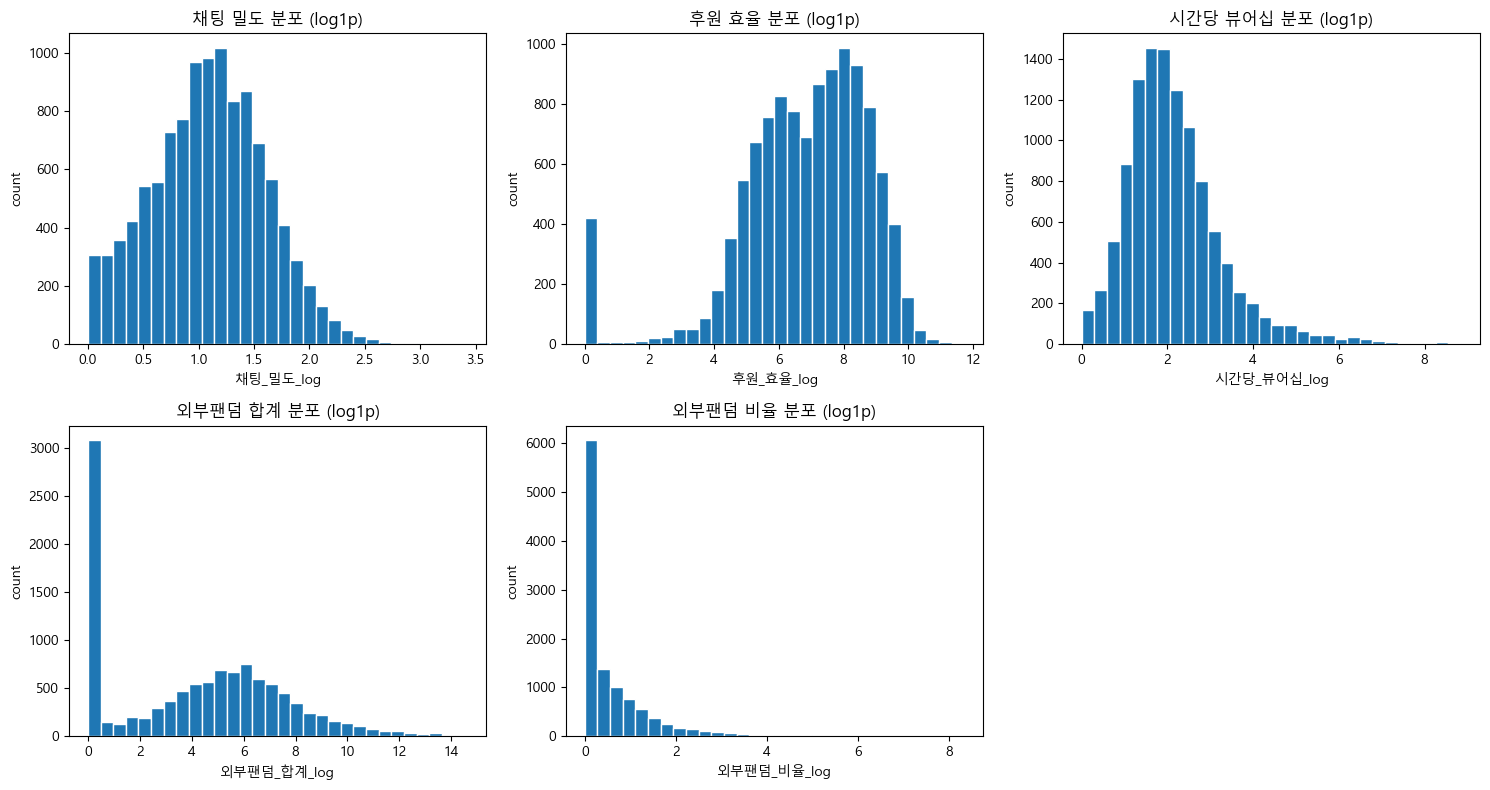

In [126]:
# 연속형 파생지표 히스토그램

# 로그 변환 컬럼 생성
eda_df["채팅_밀도_log"] = np.log1p(eda_df["채팅_밀도"])
eda_df["후원_효율_log"] = np.log1p(eda_df["후원_효율"])
eda_df["시간당_뷰어십_log"] = np.log1p(eda_df["시간당_뷰어십"])
eda_df["외부팬덤_합계_log"] = np.log1p(eda_df["외부팬덤_합계"])

hist_cols = [
    "채팅_밀도_log",
    "후원_효율_log",
    "시간당_뷰어십_log",
    "외부팬덤_합계_log",
    "외부팬덤_비율_log"
]

titles = [
    "채팅 밀도 분포 (log1p)",
    "후원 효율 분포 (log1p)",
    "시간당 뷰어십 분포 (log1p)",
    "외부팬덤 합계 분포 (log1p)",
    "외부팬덤 비율 분포 (log1p)"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    axes[i].hist(eda_df[col].dropna(), bins=30, edgecolor="white")
    axes[i].set_title(titles[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("count")

for j in range(len(hist_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### 파생지표 분포 해석

- `채팅_밀도_log`는 비교적 중앙 구간에 데이터가 집중되어 있다.  
  이는 대부분의 스트리머가 일정 수준의 채팅 반응성을 보이며, 일부 스트리머만 시청자 수 대비 높은 채팅 반응을 보인다는 것을 의미한다.

- `후원_효율_log`는 중상위 구간에 데이터가 많이 분포하고 있으며, 0 근처에도 일부 값이 존재한다.  
  이는 시청자 수 대비 후원 규모가 일정 수준 이상 나타나는 스트리머가 많지만, 후원 규모가 낮거나 없는 스트리머도 일부 존재한다는 것을 보여준다.  
  단, `도네이션` 컬럼에는 실제값과 예측값이 함께 포함되어 있으므로 실제 수익성이 아니라 시청자 대비 후원 규모를 비교하는 보조 지표로 해석해야 한다.

- `시간당_뷰어십_log`는 낮은 값에서 중간 값 구간에 많이 분포하고, 오른쪽으로 긴 꼬리를 보인다.  
  이는 대부분의 스트리머는 방송시간 대비 시청 성과가 일정 수준에 몰려 있지만, 일부 스트리머는 짧은 방송시간 대비 높은 뷰어십을 기록했을 가능성이 있음을 의미한다.

- `외부팬덤_합계_log`는 0 근처에 큰 막대가 존재하며, 이후 중간 구간에 다시 분포가 형성되어 있다.  
  이는 외부 채널 데이터가 없거나 외부 팬덤 규모가 작은 스트리머가 많지만, 외부 채널을 보유한 스트리머들 사이에서는 다양한 규모의 외부 팬덤이 존재한다는 것을 의미한다.

- `외부팬덤_비율_log`는 0 근처에 데이터가 매우 많이 몰려 있다.  
  이는 플랫폼 팔로워 대비 외부 팬덤 규모가 작거나, 외부 채널 정보가 없는 스트리머가 많다는 것을 보여준다.  
  반면 일부 스트리머는 높은 값을 보이므로, 플랫폼 외부에서 상대적으로 강한 팬덤 기반을 가진 후보군을 별도로 탐색할 필요가 있다.

---

### 7-4. 외부채널 보유 수 분포 확인

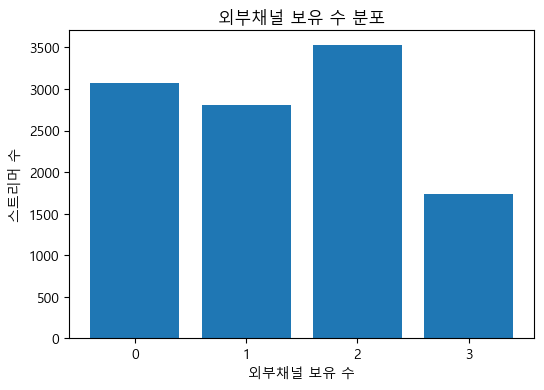

In [127]:
# 외부채널 보유수 막대그래프

channel_counts = eda_df["외부채널_보유수"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(channel_counts.index, channel_counts.values)
plt.xticks([0, 1, 2, 3])
plt.xlabel("외부채널 보유 수")
plt.ylabel("스트리머 수")
plt.title("외부채널 보유 수 분포")
plt.show()

### 정리

파생지표 분포를 확인한 결과, 단순 규모 지표로는 드러나지 않는 스트리머별 차이를 일부 확인할 수 있었다.  
특히 채팅 반응성, 후원 반응성, 방송시간 대비 성과, 외부 팬덤 확장성은 서로 다른 특성을 보여주므로 이후 세그먼트별 후보군 탐색 기준으로 활용할 수 있다.

따라서 다음 단계에서는 각 파생지표의 상위 후보군을 확인하여, 단순히 규모가 큰 스트리머가 아니라 특정 강점을 가진 스트리머 유형을 탐색한다.

---
## 8. 세그먼트별 후보군 탐색  

7번 단계에서 생성한 파생지표를 활용하여 세그먼트별 후보군을 탐색했다.  
기존의 팔로워 수, 평균 시청자 수, 뷰어십 같은 절대 규모 지표만 사용할 경우 대형 스트리머 중심으로 후보군이 형성될 가능성이 높다.

따라서 본 단계에서는 단순 규모가 아니라 **시청자 반응성**, **후원 반응성**, **방송 효율성**, **외부 팬덤 확장성**을 기준으로 스트리머를 구분하여 살펴보았다.

---

### 8-1. 세그먼트 기준 설정

본 분석에서는 파생지표를 바탕으로 다음과 같은 세그먼트 후보군을 정의했다.

| 세그먼트 | 주요 기준 | 해석 |
|---|---|---|
| 채팅 반응형 | `채팅_밀도` 상위 | 시청자 수 대비 채팅 참여가 활발한 스트리머 |
| 후원 반응형 | `후원_효율` 상위 | 시청자 수 대비 후원 규모가 큰 스트리머 |
| 방송 효율형 | `시간당_뷰어십` 상위 | 방송시간 대비 시청 성과가 높은 스트리머 |
| 외부 팬덤형 | `외부팬덤_비율_log` 상위 | 플랫폼 팔로워 대비 외부 팬덤 기반이 큰 스트리머 |
| 외부 확장형 | `외부채널_보유수` 2개 이상 | 외부 팬덤 접점을 여러 개 보유한 스트리머 |

이 기준은 확정된 최종 세그먼트라기보다, EDA 단계에서 스트리머의 특성을 탐색하기 위한 후보군 분류 기준이다.

---

### 8-2. 채팅 반응형 후보군

`채팅_밀도`가 높은 스트리머는 평균 시청자 수 대비 채팅 반응이 활발한 후보군이다.  
단순히 채팅 수가 많은 스트리머가 아니라, 시청자 규모를 고려했을 때 채팅 참여도가 높은 스트리머를 찾기 위한 기준이다.

In [128]:
chat_candidates = eda_df.sort_values("채팅_밀도", ascending=False)[[
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "평균_시청자_최댓값",
    "6분_평균채팅_최댓값",
    "채팅_밀도"
]].head(20)

chat_candidates

,스트리머명,플랫폼,최고_팔로워,평균_시청자_최댓값,6분_평균채팅_최댓값,채팅_밀도
5895,유바미,SOOP,270,13,416,29.714286
2369,유채린,SOOP,1632,51,1240,23.846154
2543,시예,SOOP,410,24,584,23.360000
1496,쮸,SOOP,3387,56,1328,23.298246
3947,유르밍,SOOP,736,22,485,21.086957
1367,더블링,SOOP,1691,76,1570,20.389610
2537,유이설,SOOP,466,27,549,19.607143
1171,한히나,SOOP,1517,44,840,18.666667
5650,LoveNaNa,SOOP,445,7,148,18.500000
11024,신애욱,CHZZK,40,0,18,18.000000


---
### 8-3. 후원 반응형 후보군

후원_효율이 높은 스트리머는 평균 시청자 수 대비 후원 규모가 큰 후보군이다. \
시청자 수가 많아서 후원 규모가 큰 경우와, 시청자 규모는 작지만 후원 반응이 강한 경우를 구분하기 위해 사용

In [129]:
donation_candidates = eda_df.sort_values("후원_효율", ascending=False)[[
    "스트리머명",
    "플랫폼",
    "평균_시청자_최댓값",
    "도네이션",
    "후원_효율"
]].head(20)

donation_candidates

,스트리머명,플랫폼,평균_시청자_최댓값,도네이션,후원_효율
540,태 림,SOOP,42,5332591,124013.744186
2582,마쏭,SOOP,24,2417809,96712.360000
807,나봄,SOOP,20,1892391,90113.857143
1322,태히 2,SOOP,16,1465477,86204.529412
3114,김대봉,SOOP,20,1621518,77215.142857
941,하루아이,SOOP,32,2545920,77149.090909
1812,뽀솜히,SOOP,18,1297366,68282.421053
1446,푸딩,SOOP,30,1996634,64407.548387
1509,예소,SOOP,31,1916499,59890.593750
1535,누야,SOOP,103,6090484,58562.346154


---
### 8-4. 방송 효율형 후보군

시간당_뷰어십이 높은 스트리머는 방송시간 대비 누적 시청 성과가 높은 후보군이다. \
뷰어십은 방송시간이 길수록 높아질 수 있기 때문에, 총 방송시간으로 나누어 방송시간의 영향을 보정했다.

In [130]:
viewership_candidates = eda_df.sort_values("시간당_뷰어십", ascending=False)[[
    "스트리머명",
    "플랫폼",
    "총_방송시간",
    "뷰어십",
    "시간당_뷰어십"
]].head(20)

viewership_candidates

,스트리머명,플랫폼,총_방송시간,뷰어십,시간당_뷰어십
4,고세구,SOOP,1558,10855404,6963.055805
15,아이네,SOOP,824,5496299,6662.180606
7,릴파,SOOP,1222,7788723,6368.538839
0,탬탬버린,CHZZK,2769,17075004,6164.261372
1,텐코 시부키,CHZZK,2368,14216251,6000.950190
3,아라하시 타비,CHZZK,2409,11350960,4709.941909
21,주르르,SOOP,1082,4794346,4426.912281
5,아야츠노 유니,CHZZK,2444,10770780,4405.226994
18,징버거,SOOP,1177,5122259,4348.267402
13,비챤,SOOP,1315,5657369,4298.912614


---
### 8-5. 외부 팬덤형 후보군

`외부팬덤_비율_log`가 높은 스트리머는 플랫폼 내부 팔로워 수 대비 외부 팬덤 규모가 큰 후보군이다.\
이는 방송 플랫폼 외부에서 이미 팬덤 기반을 확보하고 있는 스트리머를 찾기 위한 기준이다.

In [131]:
external_fandom_candidates = eda_df.sort_values("외부팬덤_비율_log", ascending=False)[[
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "X_팔로워",
    "유튜브_구독자",
    "팬카페_가입자",
    "외부팬덤_합계",
    "외부팬덤_비율",
    "외부팬덤_비율_log"
]].head(20)

external_fandom_candidates

,스트리머명,플랫폼,최고_팔로워,X_팔로워,유튜브_구독자,팬카페_가입자,외부팬덤_합계,외부팬덤_비율,외부팬덤_비율_log
9815,기록노예티로,SOOP,6,0,28800,0,28800,4114.285714,8.322464
8515,팝콘4,SOOP,142,0,0,573411,573411,4009.867133,8.296763
9843,KuraseTaoh,SOOP,11,0,17100,0,17100,1425.000000,7.262629
10180,미라클 제이,SOOP,2,0,3880,4,3884,1294.666667,7.166781
9202,고라,SOOP,9,0,11500,0,11500,1150.000000,7.048386
4629,신루,SOOP,558,0,144,573411,573555,1026.037567,6.934434
10512,채멀,SOOP,20,0,19200,0,19200,914.285714,6.819236
11152,sophiaten,SOOP,5,0,3900,0,3900,650.000000,6.478510
9581,mokiminavt,SOOP,16,0,10300,0,10300,605.882353,6.408335
4866,길앞잡이광수,SOOP,1005,0,0,573411,573411,569.991054,6.347374


우왁굳 몇명 확인되는 것 같아서 수정해야할듯..?

In [138]:
# 외부 팬덤형 후보군 산출용 데이터 복사
external_df = eda_df[eda_df["최고_팔로워"] >= 500].copy()

# 우왁굳 팬카페로 의심되는 팬카페 가입자 수 제외
# 현재 결과에서 반복적으로 나타나는 573411 값 제외
external_df = external_df[external_df["팬카페_가입자"] != 573411].copy()

# 외부 팬덤 비율 재계산
external_df["외부팬덤_합계"] = (
    external_df["X_팔로워"] +
    external_df["유튜브_구독자"] +
    external_df["팬카페_가입자"]
)

external_df["외부팬덤_비율"] = (
    external_df["외부팬덤_합계"] / (external_df["최고_팔로워"] + 1)
)

external_df["외부팬덤_비율_log"] = np.log1p(external_df["외부팬덤_비율"])

# 외부 팬덤형 후보군 재확인
external_fandom_candidates = external_df.sort_values(
    "외부팬덤_비율_log",
    ascending=False
)[[
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "X_팔로워",
    "유튜브_구독자",
    "팬카페_가입자",
    "외부팬덤_합계",
    "외부팬덤_비율",
    "외부팬덤_비율_log"
]].head(20)

external_fandom_candidates

,스트리머명,플랫폼,최고_팔로워,X_팔로워,유튜브_구독자,팬카페_가입자,외부팬덤_합계,외부팬덤_비율,외부팬덤_비율_log
6585,리코링,CHZZK,638,252000,0,0,252000,394.366197,5.979812
3894,릴리작가,CHZZK,1916,351000,801,74,351875,183.555034,5.217948
7055,시신,CHZZK,677,119000,3300,235,122535,180.730088,5.202523
7940,샨곰,CHZZK,774,5594,112000,143,117737,151.918710,5.029906
8954,나는 범이요,CHZZK,679,0,101000,400,101400,149.117647,5.011419
2612,피큐큐,CHZZK,1391,0,180000,8575,188575,135.470546,4.916109
6921,깅도이,CHZZK,2123,1400,257000,6044,264444,124.502825,4.832328
1719,해봄,SOOP,4554,0,369000,0,369000,81.009879,4.406840
175,하우카우,CHZZK,28832,13000,2210000,0,2223000,77.099157,4.357979
7369,키테라,CHZZK,1237,89000,3150,0,92150,74.434572,4.323266


---
### 8-6. 외부 확장형 후보군

`외부채널_보유수`가 2개 이상인 스트리머는 방송 플랫폼 외부에 여러 팬덤 접점을 가진 후보군이다. \
단일 외부 채널에만 의존하지 않고, 여러 채널에서 팬덤과 접촉하고 있다는 점에서 외부 확장성이 있는 스트리머로 볼 수 있다.

In [133]:
external_multi_candidates = eda_df[eda_df["외부채널_보유수"] >= 2].copy()

external_multi_candidates = external_multi_candidates.sort_values(
    ["외부채널_보유수", "외부팬덤_합계"],
    ascending=False
)[[
    "스트리머명",
    "플랫폼",
    "최고_팔로워",
    "X_팔로워",
    "유튜브_구독자",
    "팬카페_가입자",
    "외부채널_보유수",
    "외부팬덤_합계"
]].head(20)

external_multi_candidates

,스트리머명,플랫폼,최고_팔로워,X_팔로워,유튜브_구독자,팬카페_가입자,외부채널_보유수,외부팬덤_합계
11,강지,CHZZK,267338,119000,749000,252724,3,1120724
136,늦잠,CHZZK,46960,36000,900000,26652,3,962652
5,아야츠노 유니,CHZZK,281741,110000,347000,252724,3,709724
56,양아지,CHZZK,126444,42000,589000,48511,3,679511
12,아카네 리제,CHZZK,235506,93000,319000,252724,3,664724
6,시라유키 히나,CHZZK,219675,85000,302000,252724,3,639724
3,아라하시 타비,CHZZK,232937,89000,230000,252724,3,571724
17,아오쿠모 린,CHZZK,197738,73000,245000,252724,3,570724
1,텐코 시부키,CHZZK,222276,78000,204000,252724,3,534724
9,유즈하 리코,CHZZK,183957,70000,183000,252724,3,505724


---
### 8-7. 세그먼트 후보군 통합 확인

각 파생지표별 상위 후보군을 따로 확인한 뒤, 여러 세그먼트에서 반복적으로 등장하는 스트리머를 확인했다.\
여러 후보군에 동시에 포함되는 스트리머는 특정 한 지표에만 강한 것이 아니라, 복수의 관점에서 강점을 가진 후보로 볼 수 있다.

In [134]:
top_n = 20

chat_top = eda_df.nlargest(top_n, "채팅_밀도")[[
    "스트리머명", "플랫폼"
]].assign(세그먼트="채팅 반응형")

donation_top = eda_df.nlargest(top_n, "후원_효율")[[
    "스트리머명", "플랫폼"
]].assign(세그먼트="후원 반응형")

viewership_top = eda_df.nlargest(top_n, "시간당_뷰어십")[[
    "스트리머명", "플랫폼"
]].assign(세그먼트="방송 효율형")

external_top = eda_df.nlargest(top_n, "외부팬덤_비율_log")[[
    "스트리머명", "플랫폼"
]].assign(세그먼트="외부 팬덤형")

external_multi_top = (
    eda_df[eda_df["외부채널_보유수"] >= 2]
    .nlargest(top_n, "외부팬덤_합계")[["스트리머명", "플랫폼"]]
    .assign(세그먼트="외부 확장형")
)

segment_candidates = pd.concat([
    chat_top,
    donation_top,
    viewership_top,
    external_top,
    external_multi_top
], ignore_index=True)

segment_summary = (
    segment_candidates
    .groupby(["스트리머명", "플랫폼"])
    .agg(
        포함_세그먼트수=("세그먼트", "nunique"),
        포함_세그먼트=("세그먼트", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
    .sort_values(["포함_세그먼트수", "스트리머명"], ascending=[False, True])
)

segment_summary.head(30)

,스트리머명,플랫폼,포함_세그먼트수,포함_세그먼트
6,강지,CHZZK,2,"방송 효율형, 외부 확장형"
8,고세구,SOOP,2,"방송 효율형, 외부 확장형"
27,릴파,SOOP,2,"방송 효율형, 외부 확장형"
32,비챤,SOOP,2,"방송 효율형, 외부 확장형"
39,시라유키 히나,CHZZK,2,"방송 효율형, 외부 확장형"
46,아야츠노 유니,CHZZK,2,"방송 효율형, 외부 확장형"
48,아이네,SOOP,2,"방송 효율형, 외부 확장형"
49,아카네 리제,CHZZK,2,"방송 효율형, 외부 확장형"
52,엘리시아,SOOP,2,"채팅 반응형, 후원 반응형"
67,주르르,SOOP,2,"방송 효율형, 외부 확장형"


---
## 9. EDA 결과 요약 및 모델링 방향 정리